# 0105-ADV-ML-II-Dimensionality-reduction-weekly-project

## Overview
This project aims to explore and apply feature Engineering and dimensionality reduction techniques on second-hand car sales datasets. The goal is to prepare the dataset for machine learning models by creating informative features and reducing the feature space while retaining essential information. 

## Project Steps:
1. Introduction
2. Dataset Overview
3. Data Preparation
4. Feature Engineering
5. Dimensionality reduction
6. Modelling and Evaluation
7. Conclusion


## 1. Introduction
The second-hand car market is vast, and predicting the price of a used car is a challenging task due to various factors influencing the price. Feature engineering and dimensionality reduction play a crucial role in improving the performance of predictive models by enhancing the quality of input data and reducing noise.

## 2. Dataset Overview
We will use a second-hand car sales dataset containing features such as make, model, year, mileage, state, price, etc. The dataset can be obtained from public repositories like Kaggle or scraped from online car listing websites.

## 3. Data Preprocessing
### 3.1. Loading the Data
### 3.2. Data Cleaning
Handling Missing Values: Identify and handle missing values by either removing or imputing them.
Removing Duplicates: Check and remove duplicate rows.
Data Type Conversion: Ensure all features have appropriate data types.

## 4. Feature Engineering
### 4.1. Creating New Features
Car Age: Calculate the age of the car from the year of manufacture.
Price per Mile: Compute price per mile as a new feature.

### 4.2. Encoding Categorical Features
One-Hot Encoding: Apply one-hot encoding to categorical features like make, model, state, color, transmission, and fuel.

### 4.3. Feature Scaling
Standardization: Standardize numerical features to have zero mean and unit variance.

## 5. Dimensionality Reduction
### 5.1. Correlation Analysis
Correlation Matrix: Compute the correlation matrix and remove highly correlated features.

### 5.2. Principal Component Analysis (PCA)
PCA Implementation: Apply PCA to reduce the feature space while retaining most of the variance.

## 6. Modeling and Evaluation
### 6.1. Train-Test Split
Split the data into training and testing sets.
### 6.2. Model Selection
Train multiple models and select the best performing one.

## 7. Conclusion
### 7.1. Summary
Summarize the key findings and improvements from feature engineering and dimensionality reduction.
Highlight the performance of the best model.
### 7.2. Future Work
Suggest additional feature engineering techniques or data sources.
Propose further dimensionality reduction methods or advanced modeling techniques.






In [1]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# load and inspect data
df = pd.read_csv("second_hand_cars.csv")
df.head()
df.info()
df.describe(include="all")
df.isna().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

np.int64(0)

In [4]:
# clean data

# Drop unique identifier
df = df.drop(columns=["Registration Number"])

# Fill missing categorical values
df["Variant"] = df["Variant"].fillna("Unknown")
df["Accessories"] = df["Accessories"].fillna("None")

# Ensure correct types
df["Make Year"] = df["Make Year"].astype(int)
df["Mileage"] = df["Mileage"].astype(int)
df["Price"] = df["Price"].astype(int)

In [5]:
# winsorize outliers in numerical columns
# cap Mileage and Price at 1st/99th percentiles
for col in ["Mileage", "Price"]:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

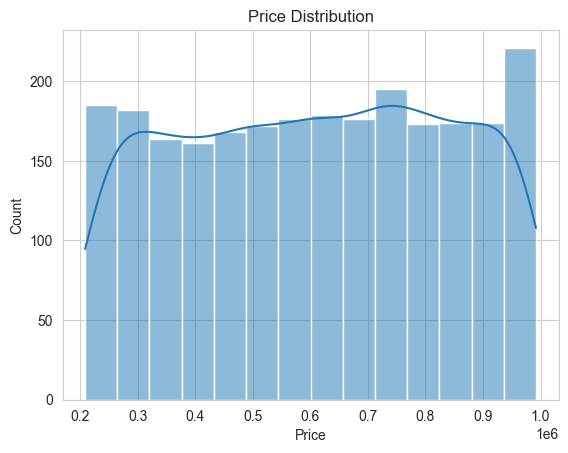

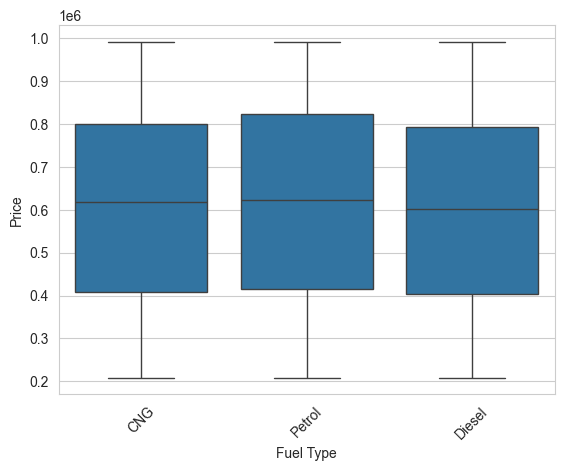

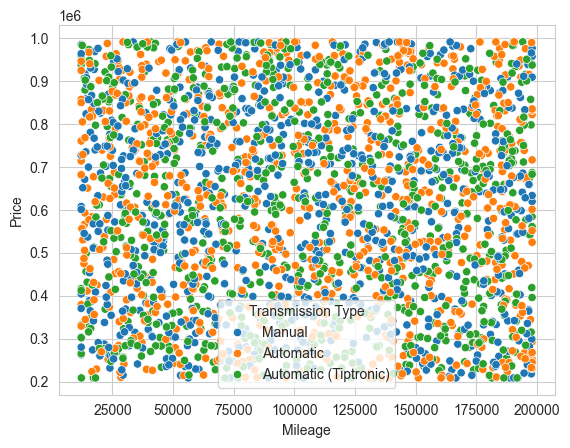

In [6]:
# EDA
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

sns.boxplot(data=df, x="Fuel Type", y="Price")
plt.xticks(rotation=45)
plt.show()

sns.scatterplot(data=df, x="Mileage", y="Price", hue="Transmission Type")
plt.show()

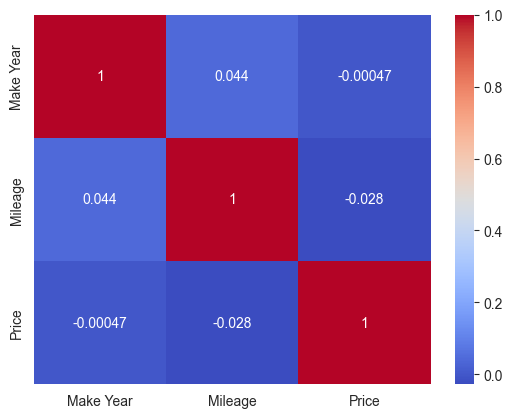

In [7]:
# numerical correlation heatmap
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [8]:
# feature engineering
current_year = 2026 

df["Car Age"] = current_year - df["Make Year"]
df["Mileage per Year"] = df["Mileage"] / (df["Car Age"] + 1)

# Accessories
accessory_list = ["Music System", "Sunroof", "Alloy Wheels", "GPS", "Leather Seats"]

for acc in accessory_list:
    df[acc] = df["Accessories"].str.contains(acc, case=False, na=False).astype(int)

df["Accessory Count"] = df[accessory_list].sum(axis=1)

# Service record 
df["Service_km"] = df["Service Record"].str.extract(r"(\d+)").astype(float)

# Binary flags
df["Has_Insurance"] = (df["Insurance"] != "No Current Insurance").astype(int)
df["Registration_Available"] = (df["Registration Certificate"] == "Available").astype(int)

# Ordinal mappings
owner_map = {"First": 1, "Second": 2, "Third": 3}
tyre_map = {"New": 1, "Used": 2, "Needs Replacement": 3}

df["Owner_Type_Ord"] = df["Owner Type"].map(owner_map)
df["Tyre_Condition_Ord"] = df["Tyre Condition"].map(tyre_map)

In [9]:
df["Price per Mile"] = df["Price"] / df["Mileage"]

In [10]:
# train/test split and preprocessing
# drop columns not needed for modeling
target = "Price"
drop_cols = [target, "Accessories", "Price per Mile", "Owner Type", "Tyre Condition"]

X = df.drop(columns=drop_cols, errors="ignore")
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# define numerical and categorical columns
numeric_features = [
    "Make Year", "Mileage", "Car Age", "Mileage per Year",
    "Service_km", "Accessory Count", "Owner_Type_Ord",
    "Tyre_Condition_Ord", "Has_Insurance", "Registration_Available"
] + accessory_list

categorical_features = [
    "Company Name", "Car Name", "Variant", "Fuel Type",
    "Transmission Type", "Body Color", "Service Record",
    "Insurance", "Registration Certificate"
]

In [12]:
# build preprocessing pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [13]:
# dimensionality reduction
X_train_pre = preprocessor.fit_transform(X_train)


In [14]:
# apply PCA inside pipeline to avoid data leakage
pca = PCA(n_components=0.95, random_state=42)

In [15]:
# modelling and evaluation
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
print(results_df.sort_values("RMSE"))

c:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.877e+12, tolerance: 1.055e+10
  model = cd_fast.enet_coordinate_descent(


               Model            MAE           RMSE        R2
4  Gradient Boosting  207605.142453  237024.274009 -0.014997
1              Ridge  206127.101406  237564.904477 -0.019633
0  Linear Regression  206759.192317  238123.339876 -0.024432
2              Lasso  207609.221425  238933.167234 -0.031412
3      Random Forest  211579.734555  242773.563377 -0.064834


In [ ]:
# relationship between numerical features and Price

numeric_cols = df.select_dtypes(include=np.number).columns
corr_with_price = df[numeric_cols].corr()["Price"].sort_values()
print(corr_with_price)

Mileage                  -0.027552
Mileage per Year         -0.022985
Service_km               -0.016144
Leather Seats            -0.010076
GPS                      -0.003091
Tyre_Condition_Ord       -0.002009
Make Year                -0.000473
Car Age                   0.000473
Music System              0.000882
Sunroof                   0.007492
Accessory Count           0.008339
Has_Insurance             0.015316
Registration_Available    0.017869
Alloy Wheels              0.029239
Owner_Type_Ord            0.034527
Price per Mile            0.350374
Price                     1.000000
Name: Price, dtype: float64


In [20]:
# with PCA
pipe_pca = Pipeline([
    ("prep", preprocessor),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("model", Ridge(random_state=42))
])
print(pipe_pca)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Make Year', 'Mileage',
                                                   'Car Age',
                                                   'Mileage per Year',
                                                   'Service_km',
                                                   'Accessory Count',
                                                   'Owner_Type_Ord',
                                                   'Tyre_Condition_Ord',
                                                   'Has_Insurance',
                    

In [19]:
# Tuning and improvisation
# use GridSearchCV
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train, y_train)

print(grid.best_params_)
best_model = grid.best_estimator_


{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}


# best model 
## Gradient Boosting achieved the lowest RMSE (237,024) and Ridge the lowest MAE (206,127). However, both had negative R² (−0.015 and −0.020 respectively), which means they perform worse than the mean-predicting baseline (R² = 0). The models are therefore not learning any useful signal; their predictions are effectively noise around the mean price.

## Limitations 
   small dataset
   synthetic looking data
   high cardinality

## future work
   collect more real data 
   better feature extraction from service records
   try XGBoost or LightGBM